# Piloto MLP de escala media

Este notebook escala la mejor condición local de 64/32 a 256/64 secuencias train/validation por régimen. Mantiene encoder directo, predictor `32→64→32`, learning rate `3e-4`, cinco seeds, 20 épocas y la evaluación de clustering congelada. No construye test.

In [1]:
# ruff: noqa: E402, E501
import json
import random
import sys
import time
from dataclasses import asdict, replace
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

from koopman_jepa.paper_config import (
    PaperCheckpointReplayConfig,
    load_paper_mlp_one_hidden_development_config,
)
from koopman_jepa.paper_data import PAPER_REGIME_NAMES, PaperRegimeDataset, generate_paper_master
from koopman_jepa.paper_evaluation import (
    evaluate_paper_mlp_clustering_gate,
    evaluate_paper_mlp_seed_clustering,
)
from koopman_jepa.paper_model import PaperTemporalJEPA
from koopman_jepa.paper_training import (
    evaluate_scale_invariant_seed_stability_gate,
    make_paper_loader,
    run_paper_train_validation_with_checkpoint,
    summarize_seed_checkpoint,
    verify_paper_checkpoint_replay,
)

plt.style.use("seaborn-v0_8-whitegrid")
torch.use_deterministic_algorithms(True)

In [2]:
config = load_paper_mlp_one_hidden_development_config(
    ROOT / "configs" / "paper_mlp_medium_scale_development.yaml"
)
selection_gate = replace(config.checkpoint_gate, min_validation_effective_rank=1.0)
replay_config = PaperCheckpointReplayConfig(metric_absolute_tolerance=1e-8)
train_dataset = PaperRegimeDataset(config.data, "train", generate_paper_master)
validation_dataset = PaperRegimeDataset(config.data, "val", generate_paper_master)
train_keys = {train_dataset.sample_key(i) for i in range(len(train_dataset))}
validation_keys = {validation_dataset.sample_key(i) for i in range(len(validation_dataset))}
assert config.data.train_per_regime == 256
assert config.data.val_per_regime == 64
assert len(train_dataset) == 256 * len(PAPER_REGIME_NAMES) == 4608
assert len(validation_dataset) == 64 * len(PAPER_REGIME_NAMES) == 1152
assert train_keys.isdisjoint(validation_keys)
assert config.model.encoder_projection == "direct"
assert config.model.mlp_depth == "one_hidden"
assert config.train.learning_rate == 3e-4
print(json.dumps(asdict(config), indent=2))
print(f"Train/validation: {len(train_dataset)}/{len(validation_dataset)}. Test no fue instanciado.")

{
  "data": {
    "master_length": 1024,
    "context_length": 768,
    "shift": 256,
    "train_per_regime": 256,
    "val_per_regime": 64,
    "test_per_regime": 64,
    "base_seed": 1,
    "normalization": "per_sequence"
  },
  "model": {
    "latent_dim": 32,
    "input_length": 768,
    "encoder_projection": "direct",
    "predictor_kind": "mlp",
    "linear_initialization": "identity",
    "mlp_depth": "one_hidden",
    "ema_decay": 0.996
  },
  "train": {
    "optimizer": "adamw",
    "learning_rate": 0.0003,
    "weight_decay": 0.0,
    "batch_size": 64,
    "epochs": 20,
    "seed": 10,
    "device": "cpu",
    "num_workers": 0
  },
  "checkpoint_gate": {
    "final_window": 2,
    "max_validation_loss_ratio": 0.5,
    "max_validation_train_loss_ratio": 4.0,
    "min_validation_embedding_std_ratio": 0.1,
    "min_validation_effective_rank": 4.0
  },
  "sweep": {
    "seeds": [
      10,
      11,
      12,
      13,
      14
    ]
  },
  "stability_gate": {
    "max_worst_vali

In [3]:
models, histories, summaries, times = {}, {}, [], {}
for seed in config.sweep.seeds:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    run_config = replace(config.train, seed=seed)
    model = PaperTemporalJEPA(config.model)
    started = time.perf_counter()
    run = run_paper_train_validation_with_checkpoint(
        model, train_dataset, validation_dataset, run_config, selection_gate
    )
    assert run.selection is not None
    replay = verify_paper_checkpoint_replay(
        model, run, validation_dataset, run_config, replay_config, expected_epoch=run.selection.epoch
    )
    assert replay.passed
    times[seed] = time.perf_counter() - started
    models[seed], histories[seed] = model, run.history
    summary = summarize_seed_checkpoint(seed, run.selection)
    summaries.append(summary)
    formal_rank = summary.validation_effective_rank >= config.checkpoint_gate.min_validation_effective_rank
    print(
        f"seed={seed} epoch={summary.checkpoint_epoch} val/base={summary.validation_loss_ratio:.3f} "
        f"gap={summary.validation_train_loss_ratio:.3f} rank={summary.validation_effective_rank:.2f} "
        f"formal_rank={'PASS' if formal_rank else 'FAIL'} time={times[seed]:.1f}s"
    )
predictive_gate = evaluate_scale_invariant_seed_stability_gate(
    summaries, config.sweep, config.stability_gate
)
formal_selection_equivalent = all(
    row.validation_effective_rank >= config.checkpoint_gate.min_validation_effective_rank
    for row in summaries
)
predictive_passed = formal_selection_equivalent and predictive_gate.passed
print(f"Predictivo formal: {'PASS' if predictive_passed else 'FAIL'}; tiempo total={sum(times.values()):.1f}s")
print(json.dumps(asdict(predictive_gate), indent=2))

seed=10 epoch=2 val/base=0.015 gap=1.042 rank=7.87 formal_rank=PASS time=143.6s


seed=11 epoch=2 val/base=0.010 gap=1.028 rank=1.95 formal_rank=FAIL time=144.0s


seed=12 epoch=1 val/base=0.015 gap=0.990 rank=7.35 formal_rank=PASS time=143.8s


seed=13 epoch=2 val/base=0.022 gap=1.045 rank=4.40 formal_rank=PASS time=144.4s


seed=14 epoch=2 val/base=0.008 gap=1.047 rank=5.33 formal_rank=PASS time=143.4s
Predictivo formal: FAIL; tiempo total=719.2s
{
  "all_checkpoints_selected": true,
  "all_finite": true,
  "mean_validation_loss_ratio": 0.0139522504119927,
  "validation_loss_ratio_coefficient_of_variation": 0.34322964392086747,
  "absolute_validation_loss_coefficient_of_variation": 0.21838821781913895,
  "worst_validation_loss_ratio": 0.02186536564404911,
  "worst_validation_train_loss_ratio": 1.047423941138956,
  "worst_validation_embedding_std_ratio": 2.8650693492047,
  "worst_validation_effective_rank": 1.9493120908737183,
  "validation_loss_passed": true,
  "generalization_gap_passed": true,
  "variability_passed": false,
  "spread_passed": true,
  "rank_passed": false,
  "passed": false
}


In [4]:
@torch.no_grad()
def collect_embeddings(model, run_config):
    device = torch.device(run_config.device)
    model.to(device).eval()
    embeddings, labels = [], []
    for context, _, batch_labels in make_paper_loader(validation_dataset, run_config, shuffle=False):
        embeddings.append(model.online_encoder(context.to(device)).cpu().numpy())
        labels.append(batch_labels.numpy())
    return np.concatenate(embeddings), np.concatenate(labels)

clustering_metrics, reference_labels = [], None
for seed in config.sweep.seeds:
    embeddings, labels = collect_embeddings(models[seed], replace(config.train, seed=seed))
    reference_labels = labels if reference_labels is None else reference_labels
    assert np.array_equal(labels, reference_labels)
    clustering_metrics.append(
        evaluate_paper_mlp_seed_clustering(embeddings, labels, seed, config.clustering)
    )
clustering_gate = evaluate_paper_mlp_clustering_gate(
    clustering_metrics, config.sweep, config.clustering_gate
)
development_passed = predictive_passed and clustering_gate.passed
print(json.dumps(asdict(clustering_gate), indent=2))
print(f"Resultado conjunto: {'PASS' if development_passed else 'FAIL'}")
print("Test no fue construido ni consultado.")

{
  "all_seeds_present": true,
  "all_finite": true,
  "overall_mean_purity": 0.49918402777777776,
  "worst_seed_mean_purity": 0.4539930555555555,
  "seed_mean_purity_coefficient_of_variation": 0.05815869040910733,
  "worst_within_seed_purity_std": 0.009973576804664876,
  "failed_seeds": [
    10,
    11,
    12,
    13,
    14
  ],
  "overall_mean_passed": false,
  "worst_seed_passed": false,
  "seed_variability_passed": true,
  "kmeans_stability_passed": true,
  "metrics": [
    {
      "seed": 10,
      "mean_purity": 0.5106770833333333,
      "purity_std": 0.009973576804664876,
      "minimum_purity": 0.4826388888888889,
      "maximum_purity": 0.5269097222222222,
      "mean_matched_accuracy": 0.46319444444444446,
      "purities": [
        0.5060763888888888,
        0.5095486111111112,
        0.5225694444444444,
        0.5052083333333334,
        0.5069444444444444,
        0.5008680555555556,
        0.5095486111111112,
        0.5138888888888888,
        0.5,
        0.5095

seed epoch val/base rank formal_rank purity_mean purity_sd
  10     2    0.015  7.87        True      51.07%     1.00%
  11     2    0.010  1.95       False      53.40%     0.98%
  12     1    0.015  7.35        True      47.83%     0.71%
  13     2    0.022  4.40        True      51.89%     0.87%
  14     2    0.008  5.33        True      45.40%     0.52%


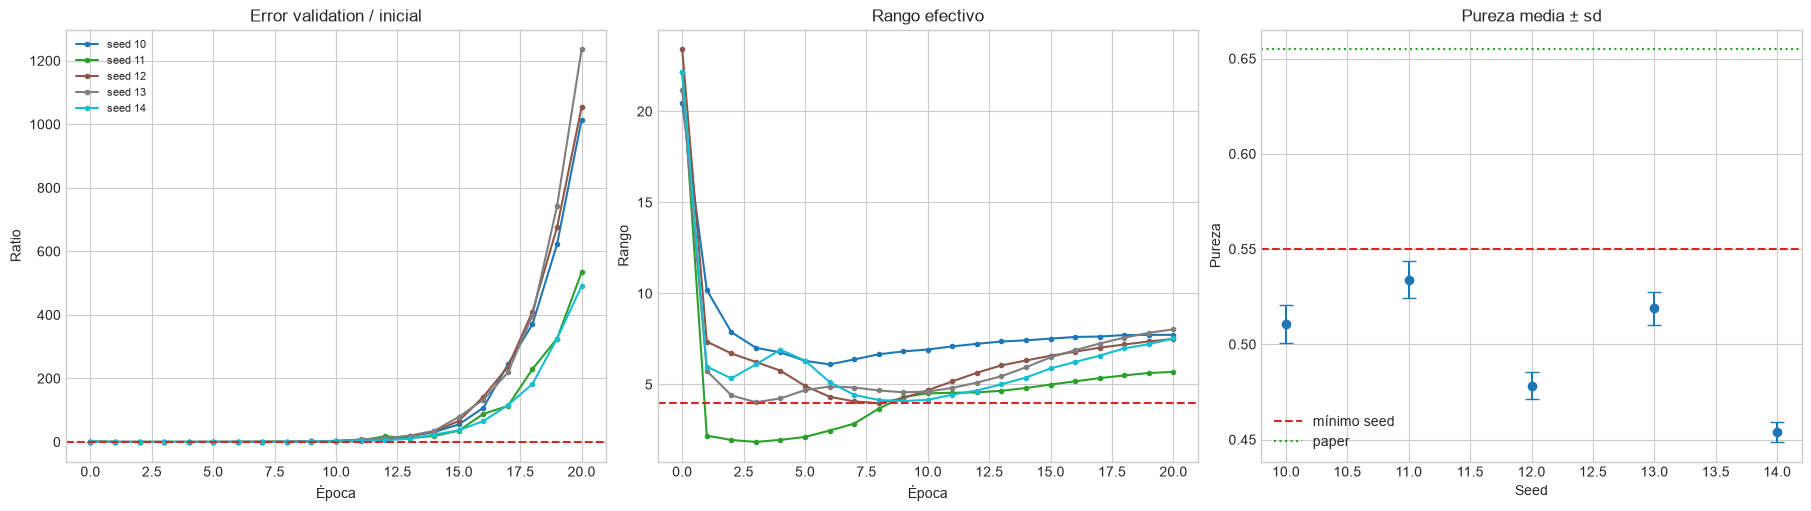

## Veredicto

- Selección: **descriptiva por rango fallido**.
- Gate predictivo: **FAIL**.
- Pureza global: **49.92%**.
- Peor seed: **45.40%**.
- Gate conjunto: **FAIL**.

Este piloto sigue muy por debajo de la escala completa del paper. Test no fue construido ni consultado.


In [5]:
summary_by_seed = {row.seed: row for row in summaries}
cluster_by_seed = {row.seed: row for row in clustering_metrics}
print("seed epoch val/base rank formal_rank purity_mean purity_sd")
for seed in config.sweep.seeds:
    summary, cluster = summary_by_seed[seed], cluster_by_seed[seed]
    formal_rank = summary.validation_effective_rank >= config.checkpoint_gate.min_validation_effective_rank
    print(
        f"{seed:>4d} {summary.checkpoint_epoch:>5d} {summary.validation_loss_ratio:>8.3f} "
        f"{summary.validation_effective_rank:>5.2f} {str(formal_rank):>11s} "
        f"{cluster.mean_purity:>11.2%} {cluster.purity_std:>9.2%}"
    )

seeds = np.array(config.sweep.seeds)
means = np.array([cluster_by_seed[seed].mean_purity for seed in seeds])
stds = np.array([cluster_by_seed[seed].purity_std for seed in seeds])
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
colors = plt.cm.tab10(np.linspace(0, 1, len(seeds)))
for color, seed in zip(colors, seeds, strict=True):
    history = histories[seed]
    epochs = np.array([row.epoch for row in history])
    losses = np.array([row.validation_loss for row in history])
    ranks = np.array([row.validation_effective_rank for row in history])
    axes[0].plot(epochs, losses / losses[0], marker="o", markersize=3, color=color, label=f"seed {seed}")
    axes[1].plot(epochs, ranks, marker="o", markersize=3, color=color)
axes[0].axhline(config.checkpoint_gate.max_validation_loss_ratio, color="tab:red", linestyle="--")
axes[0].set(title="Error validation / inicial", xlabel="Época", ylabel="Ratio")
axes[0].legend(fontsize=8)
axes[1].axhline(config.checkpoint_gate.min_validation_effective_rank, color="tab:red", linestyle="--")
axes[1].set(title="Rango efectivo", xlabel="Época", ylabel="Rango")
axes[2].errorbar(seeds, means, yerr=stds, fmt="o", capsize=5)
axes[2].axhline(config.clustering_gate.min_worst_seed_mean_purity, color="tab:red", linestyle="--", label="mínimo seed")
axes[2].axhline(0.6548, color="tab:green", linestyle=":", label="paper")
axes[2].set(title="Pureza media ± sd", xlabel="Seed", ylabel="Pureza")
axes[2].legend()
plt.show()

selection_label = "formal" if formal_selection_equivalent else "descriptiva por rango fallido"
display(Markdown(f"""## Veredicto

- Selección: **{selection_label}**.
- Gate predictivo: **{'PASS' if predictive_passed else 'FAIL'}**.
- Pureza global: **{clustering_gate.overall_mean_purity:.2%}**.
- Peor seed: **{clustering_gate.worst_seed_mean_purity:.2%}**.
- Gate conjunto: **{'PASS' if development_passed else 'FAIL'}**.

Este piloto sigue muy por debajo de la escala completa del paper. Test no fue construido ni consultado.
"""))

## Análisis posterior a la corrida

El piloto de escala media no muestra una mejora de clustering. La pureza global es `49.92%`, frente a `50.76%` en el desarrollo pequeño con la misma arquitectura. Como el aumento de train desplaza los IDs de validation, la diferencia de `−0.84` puntos no es una comparación pareada; sí es suficiente para concluir que no aparece una tendencia grande hacia el `65.48%` publicado. Las medias por seed van de `45.40%` a `53.40%`.

Cuatro de cinco checkpoints superan rango 4; seed 11 queda en `1.95`. El gate predictivo también falla por variabilidad del ratio de error (`0.343` frente a `0.25`). K-means vuelve a ser estable (CV entre seeds `0.058`, peor sd intra-seed `1.00%`), de modo que la pureza baja no es ruido de inicialización.

La pista principal está en el eje temporal. Con 4× más batches por época, los mínimos aparecen en épocas 1–2, equivalentes a unas 72–144 actualizaciones. En el desarrollo pequeño aparecían en épocas 5–7, unas 90–126 actualizaciones. Después, el error crece de forma extrema y llega a ratios de cientos al final. La inestabilidad parece depender del número de pasos de optimización, no del número de épocas ni de la cantidad de ejemplos.

Conclusión: escalar directamente a miles de ejemplos con la receta actual no está justificado. Antes de otra corrida debemos buscar una receta oficial o evidencia sobre scheduler, clipping, normalización del embedding y presupuesto de pasos. Si esa información no existe, la próxima sensibilidad debe probar una estabilización explícita y predeclarada, manteniendo claro que ya no sería una reproducción literal. Test sigue intacto.